In [2]:
import numpy as np
import pandas as pd

df=pd.read_csv('spam.csv',encoding='latin-1')[['v1','v2']]


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.columns=['label','text']
df['label']=df['label'].map({'ham':0,'spam':1})
print(df.head())

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [6]:
#Feature Engineering :Extract Numerical Features 
#  
df['text_length']=df['text'].apply(len)
df['num_words']=df['text'].apply(lambda x: len(x.split()))
df['num_digits']=df['text'].apply (lambda x: sum(c.isdigit() for c in x))

X=df[['text_length','num_words','num_digits']]
y=df['label']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
gnb.fit (x_train_scaled,y_train)
y_pred_gnb=gnb.predict(x_test_scaled)


In [11]:
from sklearn.metrics import *

print("Accuracy score: ",accuracy_score(y_test,y_pred_gnb))
print("Classification report: ",classification_report(y_test,y_pred_gnb))

print("Confusion Matrix : ",confusion_matrix(y_test,y_pred_gnb))


Accuracy score:  0.9802690582959641
Classification report:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.92      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix :  [[953  12]
 [ 10 140]]


In [33]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert text data into word count vectors
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(df['text'])

In [29]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split

# Convert counts to TF-IDF representation
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_counts)

# Split dataset
X_train, X_test, Y_train, Y_test = train_test_split(
    X_tfidf, df['label'], test_size=0.2, random_state=42
)

In [34]:
from sklearn.naive_bayes import MultinomialNB

# Train Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, Y_train)
y_pred_mnb = mnb.predict(X_test)

from sklearn.metrics import *

print("Accuracy score: ",accuracy_score(Y_test,y_pred_mnb))
print("Classification report: ",classification_report(Y_test,y_pred_mnb))

print("Confusion Matrix : ",confusion_matrix(Y_test,y_pred_mnb))

Accuracy score:  0.968609865470852
Classification report:                precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix :  [[965   0]
 [ 35 115]]


In [25]:
important_words=['free','win','offer','money','urgent']
for word in important_words:
    df[word]=df['text'].apply(lambda x: 1 if word in x.lower() else 0)

x=df[important_words]
y=df['label']


In [35]:
from sklearn.naive_bayes import BernoulliNB
bnb=BernoulliNB()
bnb.fit (x_train,y_train)
y_pred_bnb=bnb.predict(x_test)

from sklearn.metrics import *

print("Accuracy score: ",accuracy_score(y_test,y_pred_bnb))
print("Classification report: ",classification_report(y_test,y_pred_bnb))

print("Confusion Matrix : ",confusion_matrix(y_test,y_pred_bnb))

Accuracy score:  0.8654708520179372
Classification report:                precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115

Confusion Matrix :  [[965   0]
 [150   0]]


c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

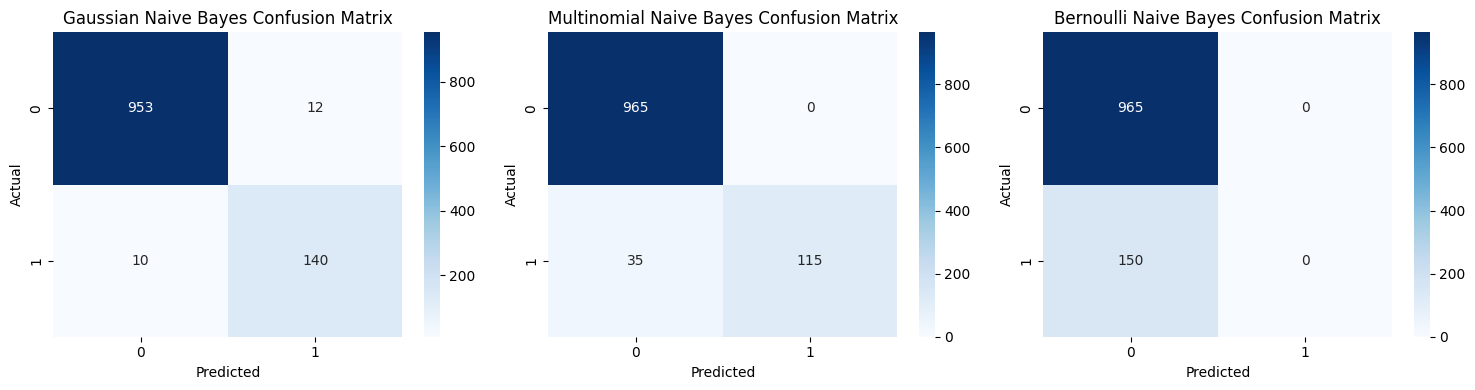

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

# Plot
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues')
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 3)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues')
plt.title("Bernoulli Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [37]:
df['label'].value_counts()
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
def predict_message(msg):
    msg_vec = vectorizer.transform([msg])
    pred = model.predict(msg_vec)[0]
    return "Suspicious" if pred == 1 else "Not Suspicious"

predict_message("Congratulations! You won ₹5000 cash")
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Correctly identified suspicious messages (TP):", tp)
print("Genuine messages incorrectly flagged (FP):", fp)

Accuracy: 0.9802690582959641
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Correctly identified suspicious messages (TP): 139
Genuine messages incorrectly flagged (FP): 11
